## Langgraph basics

In [2]:
from typing_extensions import TypedDict

In [3]:
class State(TypedDict):
    graph_state:str
    # messages: list[dict[str, str]]
    

In [10]:
def first_node(state):
    print("My First Node is called")
    return{"graph_state":state['graph_state']+" I am playing"}

def second_node(state):
    print("My Second Node is called")
    return{"graph_state":state['graph_state']+" Cricket"}

def third_node(state):
    print("My Third Node is called")
    return{"graph_state":state['graph_state']+" Hockey"}

In [5]:
from typing import Literal
import random
def decide_play(state)->Literal["second_node","third_node"]:
    graph_state=state['graph_state']
    
    if random.random()<0.5:
        return "second_node"
    
    return "third_node"

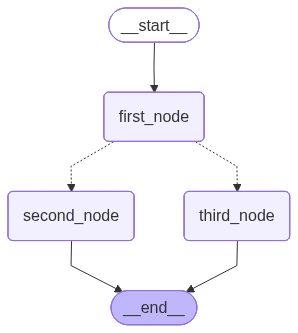

In [13]:
## construct the graph
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

builder=StateGraph(State)
builder.add_node("first_node",first_node)
builder.add_node("second_node",second_node)
builder.add_node("third_node",third_node)

#logic
builder.add_edge(START,"first_node")
builder.add_conditional_edges("first_node",decide_play)
builder.add_edge("second_node",END)
builder.add_edge("third_node",END)


#Add
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))


In [14]:
graph.invoke({"graph_state":"Hi, my name is prem,"})

My First Node is called
My Second Node is called


{'graph_state': 'Hi, my name is prem, I am playing Cricket'}

## Basic Chatbot

In [15]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages



In [16]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [17]:
graph_builder=StateGraph(State)

In [18]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [20]:
from langchain_groq import ChatGroq
model=ChatGroq(model="openai/gpt-oss-120b")
model

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001D9B10635E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001D9B10618A0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [21]:
def chatbot(state:State):
    return {"messages":[model.invoke(state["messages"])]}

In [22]:
graph_builder.add_node("chatbot",chatbot)

graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

graph=graph_builder.compile()

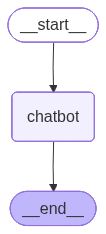

In [23]:
from IPython.display import Image,display

display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
def stream_graph_updates(user_input:str):
    for event in graph.stream({"messages":[{"role":"user","content":user_input}]}):
        for value in event.values():
            print("Assistant:",value["messages"][-1].content)

In [25]:
while True:
    try:
        user_input=input("User: ")
        if user_input.lower() in ["quit","exit","q"]:
            print("GoodBye!")
            break
        stream_graph_updates(user_input)
        
    except:
        # Fallback if input() is not avaible
        user_input="what do you know about Langgraph?"
        print("User:"+user_input)
        stream_graph_updates(user_input=user_input)
        break

Assistant: Hello! How can I help you today?
Assistant: Hello! How can I assist you today?
Assistant: ## What Machine Learning (ML) Is

Machine learning is a branch of **artificial intelligence** that gives computers the ability to **learn from data** and improve their performance on a task without being explicitly programmed for every possible scenario.  
In essence, you feed a system examples (data) and it discovers patterns, builds a model, and then uses that model to make predictions or decisions on new, unseen data.

---

## Core Concepts

| Concept | What It Means | Example |
|---------|---------------|---------|
| **Dataset** | Collection of examples (rows) and features (columns). | A table of house listings with price, size, location, etc. |
| **Feature** | An individual measurable property used as input. | “Number of bedrooms” in a house‑price dataset. |
| **Label / Target** | The output you want the model to predict. | The actual sale price of the house. |
| **Model** | A math